In [28]:
!apt-get update -qq
!apt-get install -y graphviz graphviz-dev pkg-config
!pip install pygraphviz

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
pkg-config is already the newest version (0.29.2-1ubuntu3).
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
The following packages were automatically installed and are no longer required:
  libbz2-dev libpkgconf3 libreadline-dev
Use 'apt autoremove' to remove them.
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.


In [29]:
from langgraph.graph import StateGraph, END
from typing import TypedDict

In [30]:
class AuthState(TypedDict):
  attempt: int
  authenticated: bool
CORRECT_PASSWORD = "secure123"

In [31]:
def get_password(state: AuthState) -> AuthState:
  print(f'Attempt: {state["attempt"] + 1} Enter your password: ')
  pw = input(">>")
  state["attempt"] += 1
  state["authenticated"] = pw == CORRECT_PASSWORD
  return state


In [32]:
def success_node(state:AuthState) -> AuthState:
  print("✅ Access granted! ")
  return state

In [33]:
def check_auth(state: AuthState) -> str:
  return "success" if state["authenticated"] else "retry"


In [34]:
builder = StateGraph(AuthState)
builder.add_node("get_password", get_password)
builder.add_node("success", success_node)
builder.set_entry_point("get_password")

In [35]:
builder.add_conditional_edges(
    "get_password",
    check_auth,
    {
        "success": "success",
        "retry": "get_password"
    }
)

In [36]:
builder.add_edge("success", END)

In [37]:
graph = builder.compile()

In [38]:
from IPython.display import Image, display


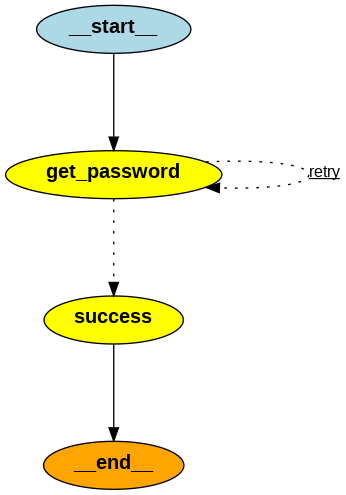

In [39]:
display(Image(graph.get_graph().draw_png()))

In [40]:
graph.invoke({
    "attempt": 0,
    "authenticated": False
})

Attempt: 1 Enter your password: 
>>fool
Attempt: 2 Enter your password: 
>>tryagain
Attempt: 3 Enter your password: 
>>secure123
✅ Access granted! 


{'attempt': 3, 'authenticated': True}